# Разработка функций расчета лучшего узла методом полного перебора

In [6]:
import osmnx as ox
import pandas as pd
import geopandas as gpd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from genesis.swiss_knife import MSF
import time

In [16]:
area = gpd.read_file("tests/data/test_polygon.gpkg")
G = ox.load_graphml("tests/data/test_rng.ml")

In [87]:
def voronoi_forest(G,
                   sources,
                   path_function,
                   nodes_mask=None,
                   cutoff=None,
                   weight='travel_time',
                   routes_return=False,
                   ):
    '''
    Расчет Леса Вороного.
    Алгоритм расчета времен прибытия первого подразделения в узлы графа.

    # Аргументы
    `G`: nx.MultiDiGraph
        Граф улично-дорожной сети.
    `sources`:list|dict
        Стартовые узлы. Может быть списком узлов вида list(int), или словарем вида dict(int:str), где ключ - 
        идентификатор узла, значение - его наименование. Может использоваться для указания узлов в которых 
        расположены пожарные подразделения: {1234:'ПСЧ-1'}
    `path_function`: function
        Функция расчета кратчайших путей от единственного источника. 
        В качестве функции могут быть переданы реализации алгоритмов из пакета
        `networkx`. Например, реализация алгоритма Дейкстры: `nx.multi_source_dijkstra`.
        Пользователь может использовать собственные функции с
        интерфейсом `func(G: Graph, sources: Any, target: Any | None = None, cutoff: Any | None = None, 
        weight: str = "weight") -> (dict, dict)`
    `nodes_mask`: pd.Series = None
        Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
        Если не указана, расчет производится для всех узлов графа.
    `cutoff`:int=None
        Ограничение расчета
    `weight`:str или function  = "travel_time"
        Имя поля содержащего вес ребер, или функция позволяющая вычислять 
        вес динамически.
    `routes_return`: bool = False
        Возвращать ли также и маршруты следования
    '''

    if not isinstance(sources, (list, dict)):
        raise TypeError('Тип данных аргумента `sources` должен быть (list или dict)')
    
    if not nodes_mask is None and not isinstance(nodes_mask, pd.Series):
        raise TypeError(f'Аргумент `points_mask` должен иметь тип `list`! Имеет {type(nodes_mask)}')

    # Расчет
    times, routes = path_function(G, sources=sources, cutoff=cutoff, weight=weight)
    times = pd.Series(times, dtype=float, name='route_time')

    # Определение стартового узла для каждого маршрута
    if isinstance(sources, dict):
        nearest = pd.Series({k:sources[route[0]] for k, route in routes.items()}, dtype=str, name='first_arrival_unit')
    else:
        nearest = pd.Series({k:route[0] for k, route in routes.items()}, dtype='int64', name='first_arrival_unit')

    # Отбор узлов по маске
    if not nodes_mask is None:
        times = times[nodes_mask]
        nearest = nearest[nodes_mask]
        if routes_return:
            routes = routes[nodes_mask]            

    # Построение леса. Потом удалить.
    # times_forest = {s:{k:v} for s,k,v in zip(nearest, times.items())}

    if routes_return:
        routes = pd.Series(routes)
        return nearest, times, routes
    else:
        return nearest, times
    
def voronoi_forest_for_area(area=None, **kwargs):
    '''
    Расчет леса Вороного и возвращение значений для набора геоданных area

    # Аргументы
    `G`: nx.MultiDiGraph
        Граф улично-дорожной сети.
    `sources`:list|dict
        Стартовые узлы. Может быть списком узлов вида list(int), или словарем вида dict(int:str), где ключ - 
        идентификатор узла, значение - его наименование. Может использоваться для указания узлов в которых 
        расположены пожарные подразделения: {1234:'ПСЧ-1'}
    `path_function`: function
        Функция расчета кратчайших путей от единственного источника. 
        В качестве функции могут быть переданы реализации алгоритмов из пакета
        `networkx`. Например, реализация алгоритма Дейкстры: `nx.multi_source_dijkstra`.
        Пользователь может использовать собственные функции с
        интерфейсом `func(G: Graph, sources: Any, target: Any | None = None, cutoff: Any | None = None, 
        weight: str = "weight") -> (dict, dict)`
    `cutoff`:int=None
        Ограничение расчета
    `weight`:str или function  = "travel_time"
        Имя поля содержащего вес ребер, или функция позволяющая вычислять 
        вес динамически.
    `routes_return`: bool = False
        Возвращать ли также и маршруты следования

    `area`:gpd.GeoDataFrame
        Геодатафрейм содержащий полигоны границ области. 
        
        Важно! Геодатафрейм должен содержать строго 1 запись!
    `**kwargs`:
        Аргументы функции `voronoi_forest`

    # Возвращает
        [nearest, times], [nearest, times, routes]:
        `nearest`:dict - словарь значений ближайших к текущему узлу стартовых узлов
        `times`:dict - словарь значений времени следования в каждый из узлов
        `routes`:dict - словарь маршрутов следования в каждый из узлов
    '''

    if area is None:
        return voronoi_forest(**kwargs)

    if not len(area)==1:
        raise ValueError('В наборе геоданных `area` должно содержаться строго 1 запись!' \
                         f'Содержится {len(area)}!')

    try:
        G = kwargs['G']
    except Exception as exc:
        raise TypeError(
            exc
            ) from exc

    if not area.crs == G.graph.get('crs'):
        raise ValueError(f'Системы координат полигона `area` ({area.crs}) и `графа` ' \
                         f'G ({G.graph.get("crs")}) не совпадают!')

    nodes = ox.graph_to_gdfs(G, edges=False)
    points_mask = nodes.within(area.iloc[0].geometry)

    return voronoi_forest(nodes_mask=points_mask, **kwargs)

Расчет простой - для всех узлов

In [ ]:
print('0', end='\r')
ndl = list(G.nodes())
start_points = {ndl[1000]:'A', 
                ndl[2000]:'B', 
                ndl[3000]:'C'}
nearest, times = voronoi_forest(G=G, 
                                sources=start_points, 
                                path_function=MSF)


print('1', end='\r')
nx.set_node_attributes(G, nearest, 'nearest')
nx.set_node_attributes(G, times, 'route_time')


print('2', end='\r')
locations = start_points

nds = ox.graph_to_gdfs(G, edges=False)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax1)
nds.plot(ax=ax1, markersize=2, column='nearest', cmap='Set3')
nds.loc[locations.keys()].plot(ax=ax1, markersize=25, color='red')

cmap1 = LinearSegmentedColormap.from_list("mycmap", ["green", "gold", "red"])
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax2)
nds.plot(ax=ax2, markersize=2, column='route_time', cmap=cmap1)
nds.loc[locations.keys()].plot(ax=ax2, markersize=25, color='red')

plt.show()

Расчет по маске

<class 'pandas.core.series.Series'>


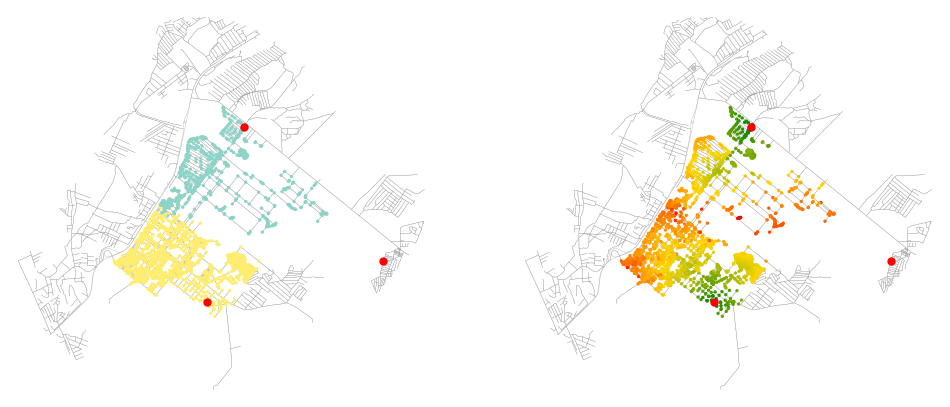

In [17]:
nodes = ox.graph_to_gdfs(G, edges=False)
mask = nodes.within(area.iloc[0].geometry)

nearest, times = voronoi_forest(G=G, 
                                sources=start_points, 
                                path_function=MSF,
                                nodes_mask=mask)


print('1', end='\r')
nx.set_node_attributes(G, nearest, 'nearest')
nx.set_node_attributes(G, times, 'route_time')


print('2', end='\r')
locations = start_points

nds = ox.graph_to_gdfs(G, edges=False)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax1)
nds.plot(ax=ax1, markersize=2, column='nearest', cmap='Set3')
nds.loc[locations.keys()].plot(ax=ax1, markersize=25, color='red')

cmap1 = LinearSegmentedColormap.from_list("mycmap", ["green", "gold", "red"])
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax2)
nds.plot(ax=ax2, markersize=2, column='route_time', cmap=cmap1)
nds.loc[locations.keys()].plot(ax=ax2, markersize=25, color='red')

plt.show()

## Расчет метрик для разных способов

In [22]:
from genesis.estimated_arrival_parameters import *
from tabulate import tabulate

In [85]:
def metrics_list(data):
    # Расчет метрик для всего результата
    metrics = {}
    metrics['mean_arr_time'] = arrival_time(np.mean)(data)
    metrics['max_arr_time'] = arrival_time(np.max)(data)
    metrics['median_arr_time'] = arrival_time(np.median)(data)

    metrics['ip5'] = cover_index(5)(data)
    metrics['ip10'] = cover_index()(data)
    metrics['ip20'] = cover_index(20)(data)

    print('-'*34)
    print(tabulate(
        pd.DataFrame(pd.Series(metrics)),
        ['Метрика', 'Показатель'],
        tablefmt='pipe'
    ))
    print('-'*34)

In [88]:
print('\nРасчет простой для 1 узла:')
start_node = [list(G.nodes())[1000]]
_, times = voronoi_forest(G, start_node, MSF)
metrics_list(times)

print('\nРасчет простой для 2 узлов:')
start_node = [list(G.nodes())[1000], list(G.nodes())[3000]]
_, times = voronoi_forest(G, start_node, MSF)
metrics_list(times)

print('\nРасчет для 2 узлов по маске:')
nodes = ox.graph_to_gdfs(G, edges=False)
mask = nodes.within(area.iloc[0].geometry)
start_node = [list(G.nodes())[1000], list(G.nodes())[3000]]
_, times = voronoi_forest(G, start_node, MSF, nodes_mask=mask)
metrics_list(times)

print('\nРасчет для 2 узлов по полигону:')
nodes = ox.graph_to_gdfs(G, edges=False)
mask = nodes.within(area.iloc[0].geometry)
start_node = [list(G.nodes())[1000], list(G.nodes())[3000]]
_, times = voronoi_forest_for_area(G=G, sources=start_node, path_function=MSF, area=area)
metrics_list(times)

print('\nРасчет для 2 узлов с ограничением по времени следования 5 минут:')
start_node = [list(G.nodes())[1000], list(G.nodes())[3000]]
_, times = voronoi_forest(G, start_node, MSF, cutoff=5)
metrics_list(times)


Расчет простой для 1 узла:
----------------------------------
| Метрика         |   Показатель |
|:----------------|-------------:|
| mean_arr_time   |      9.44882 |
| max_arr_time    |     19.3292  |
| median_arr_time |      9.4262  |
| ip5             |     13.2994  |
| ip10            |     57.9215  |
| ip20            |    100       |
----------------------------------

Расчет простой для 2 узлов:
----------------------------------
| Метрика         |   Показатель |
|:----------------|-------------:|
| mean_arr_time   |      7.27785 |
| max_arr_time    |     16.8223  |
| median_arr_time |      6.67802 |
| ip5             |     23.5828  |
| ip10            |     77.6526  |
| ip20            |    100       |
----------------------------------

Расчет для 2 узлов по маске:
----------------------------------
| Метрика         |   Показатель |
|:----------------|-------------:|
| mean_arr_time   |      5.36424 |
| max_arr_time    |      9.49328 |
| median_arr_time |      5.46449 |
| i

In [89]:
# то же что и выше, но с использованием функции nodes_metric
print('\nРасчет среднего времени прибытия простой для 1 узла:')
start_node = [list(G.nodes())[1000]]
print(nodes_metric(G=G, sources=start_node, 
                   path_function=MSF, 
                   voronoi_function=voronoi_forest, 
                   metric_function=arrival_time(np.mean)))

print('\nРасчет простой для 2 узлов:')
start_node = [list(G.nodes())[1000], list(G.nodes())[3000]]
print(nodes_metric(G=G, sources=start_node, 
                   path_function=MSF, 
                   voronoi_function=voronoi_forest, 
                   metric_function=arrival_time(np.mean)))

print('\nРасчет для 2 узлов по маске:')
nodes = ox.graph_to_gdfs(G, edges=False)
mask = nodes.within(area.iloc[0].geometry)
start_node = [list(G.nodes())[1000], list(G.nodes())[3000]]
print(nodes_metric(G=G, sources=start_node, 
                   path_function=MSF, 
                   voronoi_function=voronoi_forest, 
                   metric_function=arrival_time(np.mean), 
                   nodes_mask=mask
                   ))

print('\nРасчет для 2 узлов по полигону:')
start_node = [list(G.nodes())[1000], list(G.nodes())[3000]]
print(nodes_metric(G=G, sources=start_node, 
                   path_function=MSF, 
                   voronoi_function=voronoi_forest_for_area, 
                   metric_function=arrival_time(np.mean), 
                   area=area
                   ))

print('\nРасчет для 2 узлов с ограничением по времени следования 5 минут:')
start_node = [list(G.nodes())[1000], list(G.nodes())[3000]]
# _, times = voronoi_forest(G, start_node, MSF, cutoff=5)
print(nodes_metric(G=G, sources=start_node, 
                   path_function=MSF, 
                   voronoi_function=voronoi_forest, 
                   metric_function=arrival_time(np.mean), 
                   cutoff=5
                   ))


Расчет среднего времени прибытия простой для 1 узла:
9.448821164763288

Расчет простой для 2 узлов:
7.27785097308451

Расчет для 2 узлов по маске:
5.3642432706111505

Расчет для 2 узлов по полигону:
5.3642432706111505

Расчет для 2 узлов с ограничением по времени следования 5 минут:
4.473428138761689
